# Centro Federal de Educação Tecnológica de Minas Gerais
**Campus VIII – Varginha**  
**Bacharelado em Sistemas de Informação**  
**Disciplina:** Lab. Inteligência Artificial  
**Professor:** Lázaro Eduardo da Silva  
**Data:** 30/04/2026  
**Aluno(a):** Alvaro  Henrique Duarte Mendes 

---

### Atividade 01 - Perceptron
Esta implementação traz a solução completa orientada a objetos (via `numpy`) adicionando **gráficos e visualizações ricas** com `matplotlib` para melhor entendimento da taxa de erros durante o treinamento e a separação geométrica em 3D.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Configuração de estilo dos gráficos
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Carregamento dos Dados
Importando a base de dados de treinamento em anexo e separando as features ($x_1, x_2, x_3$) dos rótulos ($C_1 = -1$, $C_2 = +1$).

In [2]:
train_data = np.array([
    [-0.6508, 0.1097, 4.0009, -1.0000],
    [-1.4492, 0.8896, 4.4005, -1.0000],
    [2.0850, 0.6876, 12.0710, -1.0000],
    [0.2626, 1.1476, 7.7985, 1.0000],
    [0.6418, 1.0234, 7.0427, 1.0000],
    [0.2569, 0.6730, 8.3265, -1.0000],
    [1.1155, 0.6043, 7.4446, 1.0000],
    [0.0914, 0.3399, 7.0677, -1.0000],
    [0.0121, 0.5256, 4.6316, 1.0000],
    [-0.0429, 0.4660, 5.4323, 1.0000],
    [0.4340, 0.6870, 8.2287, -1.0000],
    [0.2735, 1.0287, 7.1934, 1.0000],
    [0.4839, 0.4851, 7.4850, -1.0000],
    [0.4089, -0.1267, 5.5019, -1.0000],
    [1.4391, 0.1614, 8.5843, -1.0000],
    [-0.9115, -0.1973, 2.1962, -1.0000],
    [0.3654, 1.0475, 7.4858, 1.0000],
    [0.2144, 0.7515, 7.1699, 1.0000],
    [0.2013, 1.0014, 6.5489, 1.0000],
    [0.6483, 0.2183, 5.8991, 1.0000],
    [-0.1147, 0.2242, 7.2435, -1.0000],
    [-0.7970, 0.8795, 3.8762, 1.0000],
    [-1.0625, 0.6366, 2.4707, 1.0000],
    [0.5307, 0.1285, 5.6883, 1.0000],
    [-1.2200, 0.7777, 1.7252, 1.0000],
    [0.3957, 0.1076, 5.6623, -1.0000],
    [-0.1013, 0.5989, 7.1812, -1.0000],
    [2.4482, 0.9455, 11.2095, 1.0000],
    [2.0149, 0.6192, 10.9263, -1.0000],
    [0.2012, 0.2611, 5.4631, 1.0000]
])

X_train = train_data[:, :3]
y_train = train_data[:, 3]

## 2. Classe Perceptron Aprimorada
Agora com rastreamento histórico de erros em cada época para plotagem de gráficos.

In [3]:
class Perceptron:
    def __init__(self, learning_rate=0.01, random_state=None):
        self.learning_rate = learning_rate
        self.random_state = random_state
        self.weights = None
        self.w0 = None 
        self.epochs = 0
        self.initial_weights = None
        self.final_weights = None
        self.error_history = []

    def fit(self, X, y):
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        self.weights = np.random.rand(X.shape[1])
        self.w0 = np.random.rand(1)[0]
        self.initial_weights = np.concatenate(([self.w0], self.weights))
        
        epochs = 0
        has_errors = True
        
        while has_errors:
            has_errors = False
            epochs += 1
            errors_in_epoch = 0
            
            for xi, target in zip(X, y):
                v = np.dot(xi, self.weights) + self.w0 * (-1)
                y_pred = 1.0 if v >= 0 else -1.0
                
                if target != y_pred:
                    update = self.learning_rate * target
                    self.weights += update * xi
                    self.w0 += update * (-1)
                    has_errors = True
                    errors_in_epoch += 1
            
            self.error_history.append(errors_in_epoch)
                    
        self.final_weights = np.concatenate(([self.w0], self.weights))
        self.epochs = epochs

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.w0 * (-1)
        return np.where(linear_output >= 0, 1.0, -1.0)


## 3. Treinamento e Gráficos de Convergência
Abaixo executamos o treinamento 5 vezes e plotamos o gráfico com o número de erros a cada época.

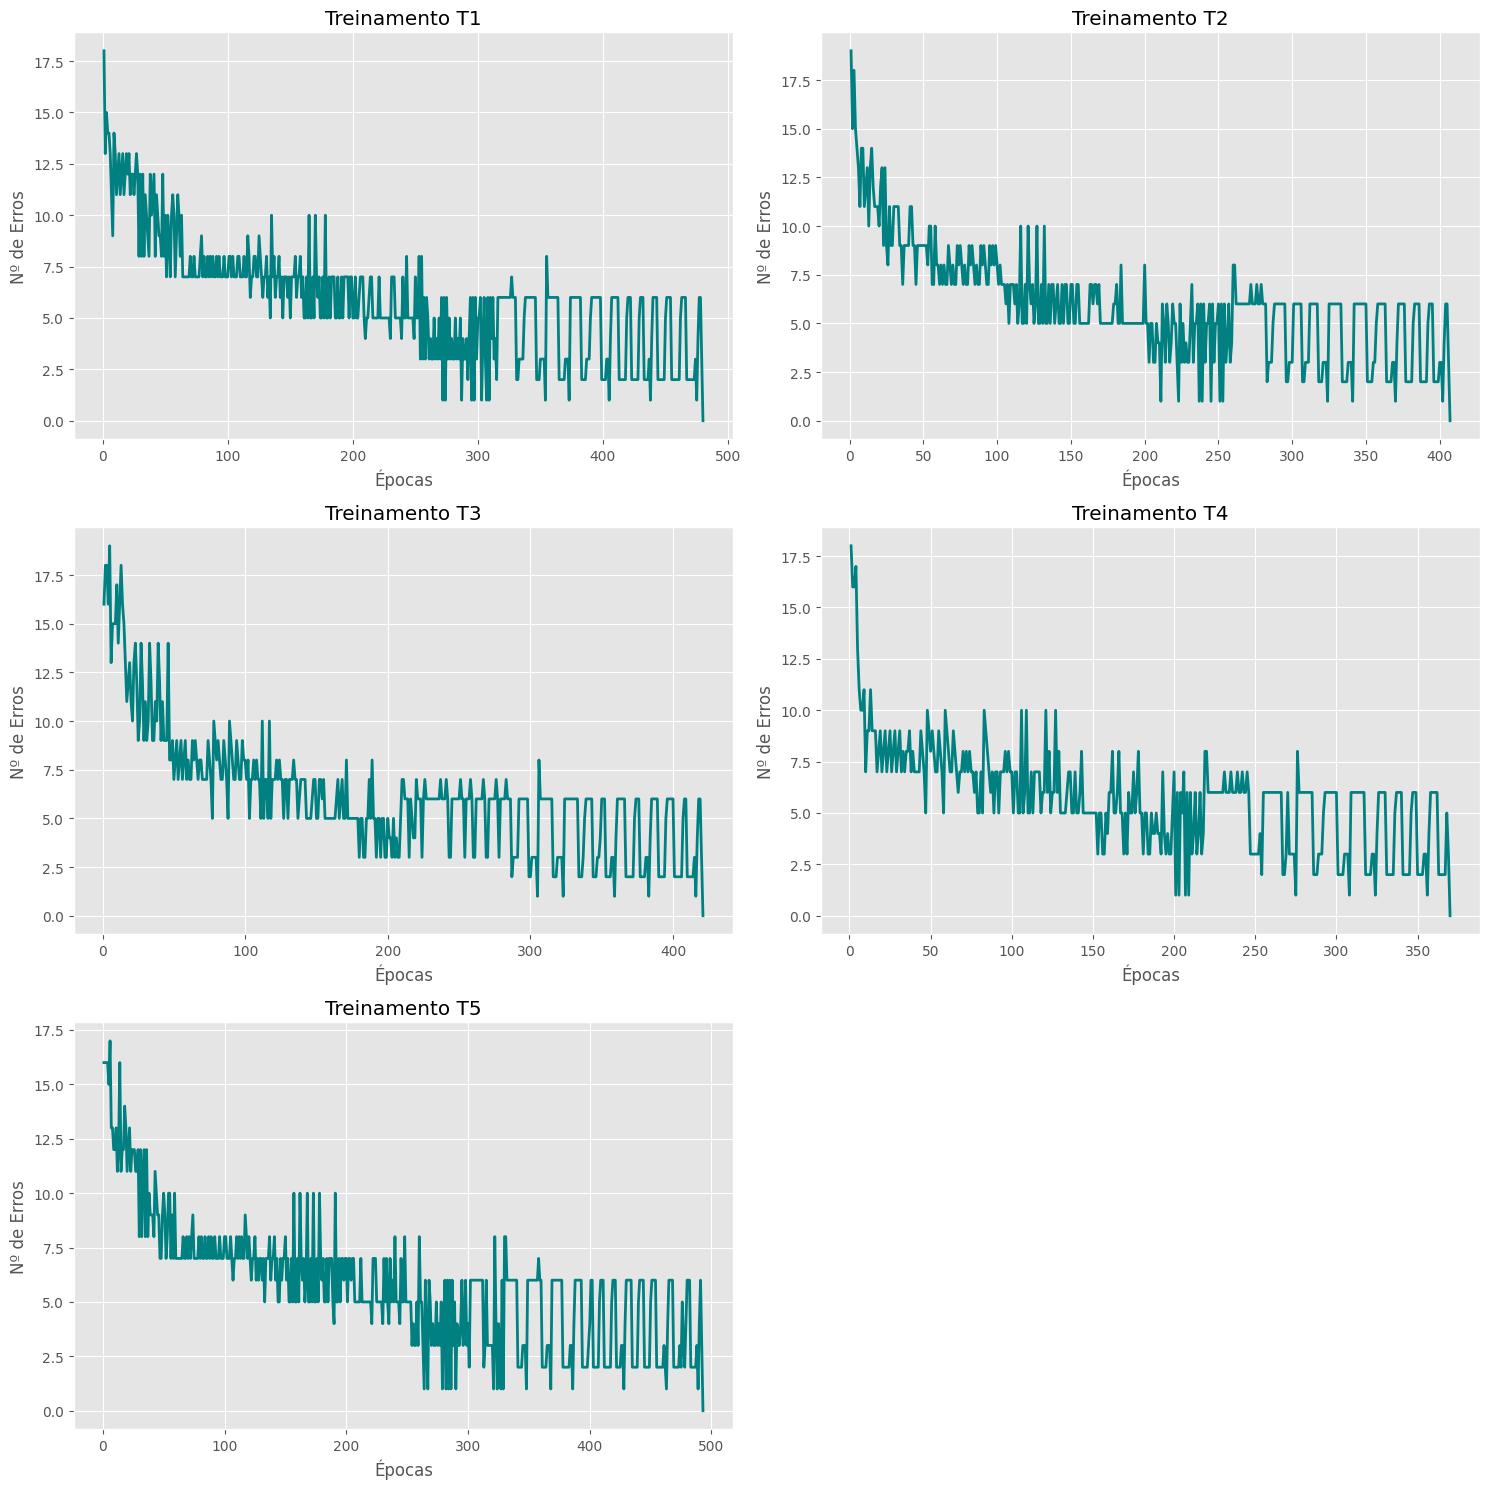


--- TABELA 1: RESULTADOS DOS TREINAMENTOS ---



,Treinamento,w0_ini,w1_ini,w2_ini,w3_ini,w0_fin,w1_fin,w2_fin,w3_fin,Épocas
0,T1,0.5987,0.3745,0.9507,0.7320,-1.5613,0.7959,1.2585,-0.3734,480
1,T2,0.2406,0.1151,0.6091,0.1334,-1.5394,0.7673,1.2313,-0.3656,407
2,T3,0.3605,0.8348,0.1048,0.7446,-1.5495,0.7856,1.2441,-0.3695,421
3,T4,0.0773,0.9890,0.5495,0.2814,-1.5127,0.7570,1.2288,-0.3620,370
4,T5,0.7581,0.7838,0.6348,0.2490,-1.5619,0.7896,1.2600,-0.3716,493


In [4]:
models = []
table_1 = []

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for i in range(5):
    p = Perceptron(learning_rate=0.01, random_state=42+i)
    p.fit(X_train, y_train)
    models.append(p)
    
    table_1.append({
        'Treinamento': f"T{i+1}",
        'w0_ini': np.round(p.initial_weights[0], 4),
        'w1_ini': np.round(p.initial_weights[1], 4),
        'w2_ini': np.round(p.initial_weights[2], 4),
        'w3_ini': np.round(p.initial_weights[3], 4),
        'w0_fin': np.round(p.final_weights[0], 4),
        'w1_fin': np.round(p.final_weights[1], 4),
        'w2_fin': np.round(p.final_weights[2], 4),
        'w3_fin': np.round(p.final_weights[3], 4),
        'Épocas': p.epochs
    })
    
    # Plot de Erros
    axes[i].plot(range(1, p.epochs + 1), p.error_history, color='teal', linewidth=2)
    axes[i].set_title(f'Treinamento T{i+1}')
    axes[i].set_xlabel('Épocas')
    axes[i].set_ylabel('Nº de Erros')

axes[5].axis('off')
plt.tight_layout()
plt.show()

print("\n--- TABELA 1: RESULTADOS DOS TREINAMENTOS ---\n")
df_table1 = pd.DataFrame(table_1)
display(df_table1)

## 4. Visualização 3D do Hiperplano de Separação
Para entender o que o perceptron faz visualmente, plotamos os dados originais no espaço 3D ($x_1, x_2, x_3$) junto com o plano hiperplano aprendido pelo treinamento **T1**.

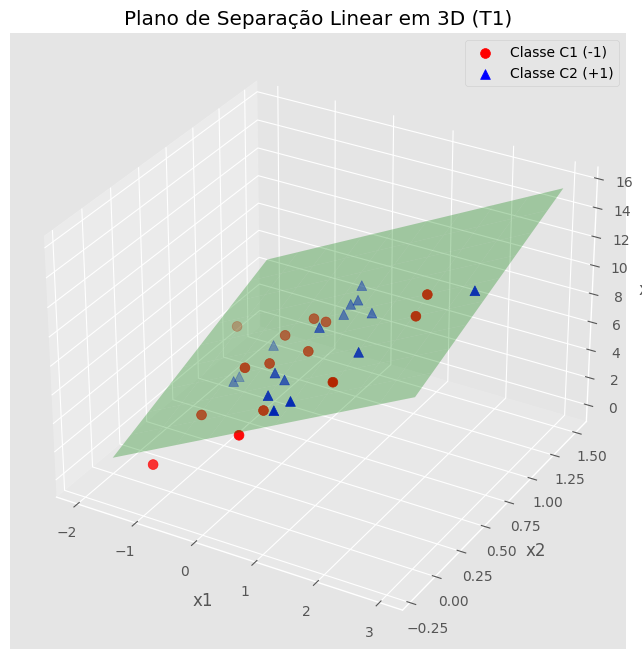

In [5]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Pontos das classes C1 e C2
c1 = train_data[train_data[:, 3] == -1]
c2 = train_data[train_data[:, 3] == 1]

ax.scatter(c1[:, 0], c1[:, 1], c1[:, 2], color='red', s=50, label='Classe C1 (-1)', marker='o')
ax.scatter(c2[:, 0], c2[:, 1], c2[:, 2], color='blue', s=50, label='Classe C2 (+1)', marker='^')

# Extrair pesos finais do modelo T1 para construir o plano
w0, w1, w2, w3 = models[0].final_weights

# Gerar malha (mesh) para o plano
xx, yy = np.meshgrid(np.linspace(-2, 3, 10), np.linspace(0, 1.5, 10))
zz = (w0 - w1*xx - w2*yy) / w3

ax.plot_surface(xx, yy, zz, alpha=0.3, color='green')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
ax.set_title('Plano de Separação Linear em 3D (T1)')
plt.legend()
plt.show()

## 5. Comparativo de Épocas
Gráfico de barras para evidenciar a variância na convergência (resposta visual à primeira pergunta teórica).

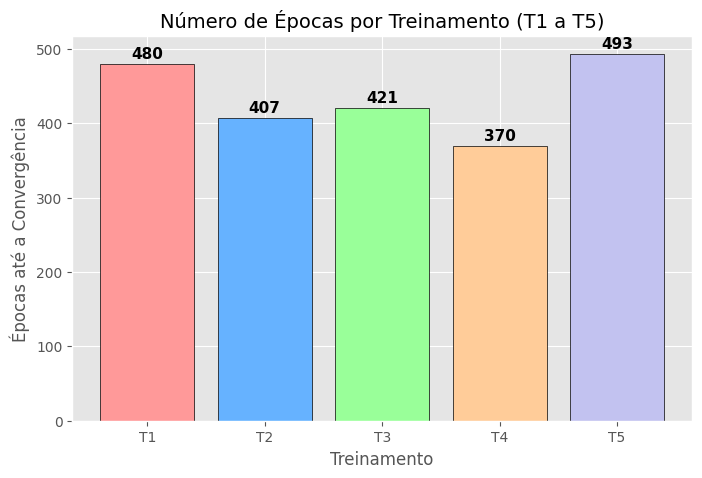

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
trainings = [f'T{i+1}' for i in range(5)]
epochs_counts = [p.epochs for p in models]
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#c2c2f0']

bars = ax.bar(trainings, epochs_counts, color=colors, edgecolor='black')
ax.set_title('Número de Épocas por Treinamento (T1 a T5)', fontsize=14)
ax.set_xlabel('Treinamento', fontsize=12)
ax.set_ylabel('Épocas até a Convergência', fontsize=12)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 3, f'{height}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()

## 6. Classificação (Tabela 2)
Resultados da inferência dos 5 modelos gerados para as novas amostras listadas no escopo.

In [7]:
X_test = np.array([
    [-0.3565, 0.0620, 5.9891],
    [-0.7842, 1.1267, 5.5912],
    [0.3012, 0.5611, 5.8234],
    [0.7757, 1.0648, 8.0677],
    [0.1570, 0.8028, 6.3040],
    [-0.7014, 1.0316, 3.6005],
    [0.3748, 0.1536, 6.1537],
    [-0.6920, 0.9404, 4.4058],
    [-1.3970, 0.7141, 4.9263],
    [-1.8842, -0.2805, 1.2548]
])

table_2 = []
for i, x in enumerate(X_test):
    row = {'Amostra': i+1, 'x1': x[0], 'x2': x[1], 'x3': x[2]}
    for j, p in enumerate(models):
        row[f'y(T{j+1})'] = p.predict([x])[0]
    table_2.append(row)

print("\n--- TABELA 2: CLASSIFICAÇÃO ---\n")
df_table2 = pd.DataFrame(table_2)
display(df_table2)


--- TABELA 2: CLASSIFICAÇÃO ---



,Amostra,x1,x2,x3,y(T1),y(T2),y(T3),y(T4),y(T5)
0,1,-0.3565,0.0620,5.9891,-1.0,-1.0,-1.0,-1.0,-1.0
1,2,-0.7842,1.1267,5.5912,1.0,1.0,1.0,1.0,1.0
2,3,0.3012,0.5611,5.8234,1.0,1.0,1.0,1.0,1.0
3,4,0.7757,1.0648,8.0677,1.0,1.0,1.0,1.0,1.0
4,5,0.1570,0.8028,6.3040,1.0,1.0,1.0,1.0,1.0
5,6,-0.7014,1.0316,3.6005,1.0,1.0,1.0,1.0,1.0
6,7,0.3748,0.1536,6.1537,-1.0,-1.0,-1.0,-1.0,-1.0
7,8,-0.6920,0.9404,4.4058,1.0,1.0,1.0,1.0,1.0
8,9,-1.3970,0.7141,4.9263,-1.0,-1.0,-1.0,-1.0,-1.0
9,10,-1.8842,-0.2805,1.2548,-1.0,-1.0,-1.0,-1.0,-1.0


## 7. Respostas Teóricas

**1. Explique por que o número de épocas de treinamento varia a cada vez que executamos o treinamento do perceptron.**

O algoritmo de aprendizado do perceptron ajusta os pesos iterativamente até que todas as amostras de treinamento sejam classificadas corretamente. Como os pesos iniciais em cada treinamento (T1 a T5) são gerados aleatoriamente, a inclinação e a posição iniciais da reta (hiperplano) de separação diferem em cada execução. Consequentemente, o número de ajustes necessários (épocas) para posicionar o hiperplano no local ideal de separação também varia. Quanto mais distante a inicialização aleatória dos pesos se encontrar do plano ótimo, mais épocas iterativas serão necessárias para o algoritmo convergir.

**2. Qual a principal limitação do perceptron quando aplicado em problemas de classificação de padrões.**

A principal limitação do Perceptron Simples de camada única é que ele só consegue resolver problemas que são **linearmente separáveis**. Isso significa que ele apenas pode aprender e separar classes cujos dados correspondam a fronteiras de separação perfeitas e retas (um hiperplano). Se as classes tiverem sobreposições complexas ou dependerem de lógicas não-lineares (como o clássico problema da porta lógica XOR), o perceptron falhará e ficará oscilando os pesos num loop infinito sem nunca convergir perfeitamente.